# Visualising the pulsar data

You can use this notebook to visualise the frequency vs phase data you recorded from the telescope.

## Using the notebook

You can write python code in the cells. Execute the code with Ctrl-Enter. The results are displayed below the cell.

Cells can also contain annotations like this one. A cell can be toggled between code and "[markdown](https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet)" in the drop-down menu above. The annotation cells can be written in plain text, but also support markdown formatting, a cheat-sheet for which can be found at the above link. Double-click to edit the text, and Ctrl-Enter return to the formated version. Try it on this comment.

## Load the required libraries

We mainly make use of two libraries in this template: Numpy and matplotlib. You may be familiar with these from other courses.

Numpy provides routines for doing lots of math stuff. For example, here we use the numpy.loadtxt routine to read a text file and convert the characters to numbers with just a single line of code. Here we import the numpy library with a short name `np`

We will import the matplotlib package as `plt` in order to use it to make all kinds of plots.

Numpy (and the related scipy) have very powerful tools for doing all kinds of operations, including fitting functions to data. You can find lots of information on these methods if you search around the web and in the numpy manual, and do talk to your demonstrator.

We don't need all these just for plotting, but some e.g. astropy might be very useful for other tasks.


In [ ]:
# To begin, we import some libraries that we will need later.

# The numpy library will allow us to do FFTs
import numpy as np

# The pyplot module from matplotlib will allow us to plot things.
from  matplotlib import pyplot as plt

# pi is a useful value!
from math import pi

import os

## Connect to your google drive to allow you to read data files

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [ ]:
# A good test to do is if you can see the contents of the directory in which you work on your google drive.
# Here "My Drive" refers to the "root" of your google drive.
# By default your notebook should be in a directory called Colab Notebooks.
# This template assumes all files you want to read in are copied in the
# same directory. Note the slash at the end of the first line.
#pathcrabtemplate = rootpathdrive+'/'+'My Drive/Colab Notebooks/CrabPulsar/Crab_pulsar_template/'
pathcrabtemplate = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathcrabtemplate):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.

['README.md', 'LICENSE', 'template.txt', '.gitignore', '20251007_100808_B0329+54.npz', '20251007_110422_B0950+08.npz', '20251007_121203_B1933+16.npz', '20251007_134605_B2021+51.npz', '2025_ssb.txt', '20251021_071206_B0531+21.npz.toas.txt', '20251007_121203_B1933+16.npz.toas.txt', '20251111_091248_B1133+16.npz', '20251111_054931_B0531+21.npz', '20251111_114643_B1929+10.npz', '20251021_083354_B0531+21.npz', '20251119_184501_B0531+21.npz', '20251119_184501_B0531+21.npz.toas.txt', '20251111_054931_B0531+21.npz.toas.txt', 'WORKING Make Time of Arrivals.ipynb', '20251111_130236_B2016+28.npz', '20251021_134059_B2020+28.npz', '20251021_071206_B0531+21.npz', '20251021_102701_B1133+16.npz', '20251111_113619_B1919+21.npz', '20251125_100607_B1804-08.npz', '20251125_121227_B1642-03.npz', 'WORKING Searching for Pulsars.ipynb', 'Questions in Script + FAQ.gdoc', 'Finley and Sara - Digital Lab Notebook .gslides', 'Interview Presentation.gslides', 'Untitled drawing.gdraw', "WORKING 20251119 Patrick's Cr

## Read the file and make a plot

We will use the psrchive software to load the data. The provided `load_channels()` method will read the data into a `numpy` array. </br>

List of files to use: </br>
example_data/20220522_051826_B0329+54.npz </br>


In [ ]:
#7 OCT
#example_data/20220522_051826_B0329+54.npz
#20251007_100808_B0329+54.npz
#20251007_110422_B0950+08.npz
#20251007_121203_B1933+16.npz
#20251007_134605_B2021+51.npz

#21 OCT
#20251021_071206_B0531+21.npz #Crab
#20251021_134059_B2020+28.npz
#20251021_102701_B1133+16.npz


#11 Nov
#20251111_114643_B1929+10.npz
#20251111_054931_B0531+21.npz

#19th
#20251119_184501_B0531+21.npz

In [ ]:
# Use the numpy loadtxt routine to read data.

# this is an example file, change it to point at your data.
filename=os.path.join(pathcrabtemplate, "20251119_184501_B0531+21.npz")
obsdata = np.load(filename)
print(obsdata['header'])
print("")

data = obsdata['data']
print("Data array shape:",data.shape)

Filename                      : 20251119_184501_B0531+21.cln
Source Name                   : B0531+21
Number of channels            : 40
Number of phase bins          : 1024
Number of sub-integrations    : 161
Centre Freq (MHz)             : 611.0
Bandwidth (MHz)               : 10.0
Integration Time (s)          : 32171.999708
Telescope                     : Jodrell

Data array shape: (161, 40, 1024)


### Plotting

We have read a 2-d `numpy` array which we can then plot using `matplotlib`.


The code then plots a 2-d plot showing intensity as a function of frequency and phase. This is the **phase vs frequency** plot. We can also integrate over frequency by summing along the first axis of the array. This produces **intensity vs phase** plot.

Check you understand what you are seeing in these plots. Discuss them with your demonstrator.

Nsub = 161 Nchan = 40 Nphase= 1024
[[-1.7128357e-03 -5.6659826e-04 -3.0530661e-03 ... -1.3032007e-04
   1.4347247e-03 -1.6722362e-03]
 [ 1.6307658e-04  1.2463464e-03 -5.2427489e-04 ...  5.8330595e-04
  -1.8118089e-03  5.6983792e-04]
 [-4.0454412e-04  9.5275586e-04 -2.6701894e-03 ... -6.1902480e-04
  -1.1709161e-03 -5.7519099e-04]
 ...
 [-1.9301306e-03  5.5294519e-04  1.5879786e-03 ... -6.0886354e-04
  -2.1366633e-03 -3.0151457e-03]
 [ 3.0114764e-04  1.5317703e-03  3.0350866e-05 ...  1.3434252e-03
  -2.5258325e-03  1.4005185e-04]
 [ 4.9006363e-04  1.9768756e-03  1.5389273e-03 ... -8.1486005e-04
  -8.4685795e-05 -5.5224367e-04]]
(161, 1024)


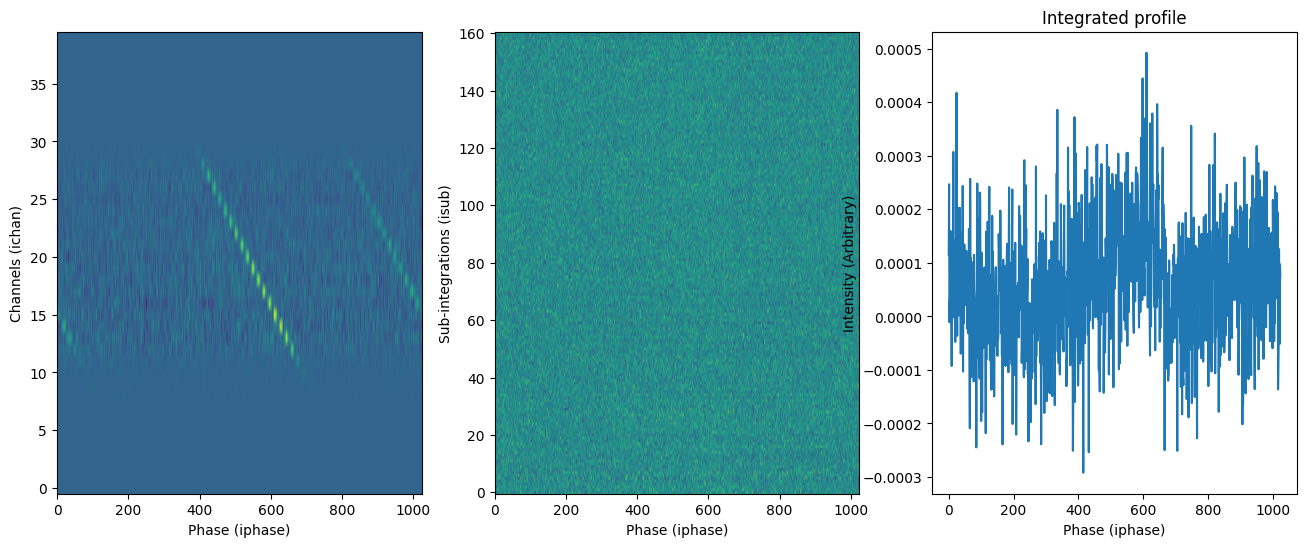

In [ ]:
# Here we infer the number of channels and numnber of phase bins based on the last entry in the file.
nsub, nchan,nphase = data.shape

# Print this out for verification
print("Nsub = {} Nchan = {} Nphase= {}".format(nsub, nchan,nphase))


# Here is where we reshape the 1-d array into a 2-d data structure
iphase=np.arange(nphase)
ichan=np.arange(nchan)
isub = np.arange(nsub)

# We can integrate over all frequency channels by using the `sum` routine from numpy...
fully_averaged=np.mean(data,axis=(0,1))
time_averaged = np.mean(data,axis=0)
freq_averaged = np.mean(data,axis=1)
print(freq_averaged)
print(np.shape(freq_averaged))


# Plot the 2-d data:
plt.figure(figsize=(16,6))
plt.subplot(131)
plt.imshow(time_averaged,aspect='auto',origin='lower')
plt.xlabel("Phase (iphase)")
plt.ylabel("Channels (ichan)")

plt.subplot(132)
plt.imshow(freq_averaged,aspect='auto',origin='lower')
plt.xlabel("Phase (iphase)")
plt.ylabel("Sub-integrations (isub)")

# Plot the integrated profile:
plt.subplot(133)
plt.plot(fully_averaged)
plt.xlabel("Phase (iphase)")
plt.ylabel("Intensity (Arbitrary)")
plt.title("Integrated profile")
plt.show()

## Dispersion

The pulsar signal experiences a frequency dependent delay caused by the interstellar plasma. This should be visiable in the frequency vs phase plot as a drift in the pulse as a function of frequency. This is called dispersion.

In order to measure and correct for the dispersion, you will need to convert the axes of your data to physical units.

The frequency axis can be determined from the central frequency and bandwidth of your instrument
The time axis can be determined from the period of the pulsar and the number of phase bins.


### De-dispersion
Correcting for the dispersion requires shifting the rows of your 2-d array by a frequency dependent time delay equal to the negative of the dispersion induced delay. This process is called "de-dispersion". Once de-dispersed, integrating over frequency channels should give improved signal-to-noise and a narrower pulse.

To get you started, we have provided a function `shift_rows` which will rotate each row of a 2-d matrix by the number of bins specified in the `shifts` array.

The demo program will use this to shift each row by an arbitrary amount, you will need to modify the program to shift by the time delay caused by a given "dispersion measure" (DM). Read the lab script for more information about how to compute this time delay.

Modify this program to correct the data for a given DM. Try a few values of DM (see if you can find common values for dispersion measure of pulsars) and see if you can roughly detrmine the value that maximises the DM. Check with your demonstrator if your DM value is sensible. You should extend your program to try to determine the DM in a more rigourous way. There are many ways to do this, if you are stuck, discuss with your demonstrator.

In [ ]:
##
#  This function will shift each row of a 2-d (3-d) array by the the number of columns specified in the "shifts" array.
#  data_in - the 2-d (3-d) array to work on
#  shifts - the shifts to apply
#  Returns: The shifted array
##
def shift_rows(data_in, shifts):
    shifted = np.zeros_like(data_in)
    if data_in.ndim == 3:
        for sub in range(nsub):
            shifted[sub] = shift_rows(data_in[sub],shifts)
    else:
        for chan in range(nchan):
            shifted[chan] = np.roll(data_in[chan],int(shifts[chan]))
    return shifted


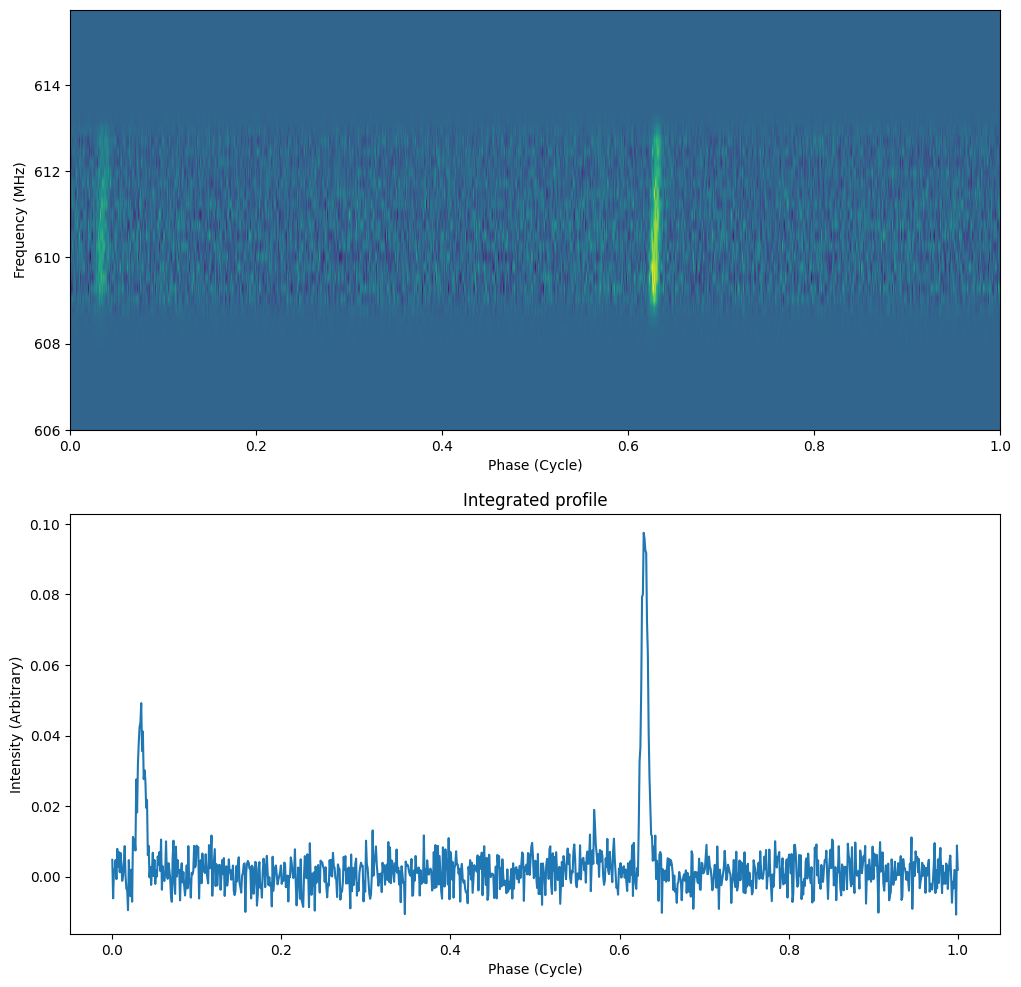

In [ ]:
# constants
bandwidth = 10e6  # Hz
dispersion_measure = 56.7580 #pc cm^-3
freq = 606 + ichan * 0.25  # MHz (assuming 40 channels spanning 10 MHz)
f_ref = np.max(freq)  # reference (highest) frequency
pulse_freq = 1/0.033392
period = 0.033392
multiplier = period/1024 # integration time


# dispersion delay for each frequency channel, in seconds
time_delay = (dispersion_measure / (2.410*(10**(-4))*freq**2)) / (period/1024)

# convert delay to phase shift (radians)
#phase_shift = 2 * np.pi * pulse_freq * time_delay * 1/multiplier

# number of bins to shift by
bindelay = -time_delay
#phase_shift / (2 * np.pi) * nphase  # convert phase to bins

# apply the frequency-dependent shift
dedispersed = shift_rows(time_averaged, bindelay)

# sum over frequency to get 1D profile
integrated = np.sum(dedispersed, axis=0)

# plot the data again... If you have de-dispersed correctly, you the S/N should be maximised.
plt.figure(figsize=(12,12))
plt.subplot(211)

# Here we show how to change the scaling of the axes so that they have physical units.
plt.imshow(dedispersed,aspect='auto',origin='lower',extent=(0,1,freq[0],freq[-1]))
plt.xlabel("Phase (Cycle)")
plt.ylabel("Frequency (MHz)")


plt.subplot(212)
plt.plot(np.linspace(0,1,nphase),integrated)
plt.xlabel("Phase (Cycle)")
plt.ylabel("Intensity (Arbitrary)")
plt.title("Integrated profile")
plt.show()

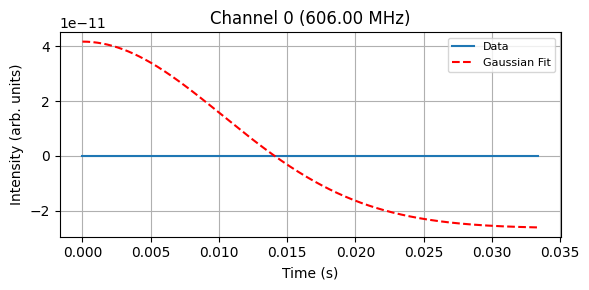

Channel 0 (606.00 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



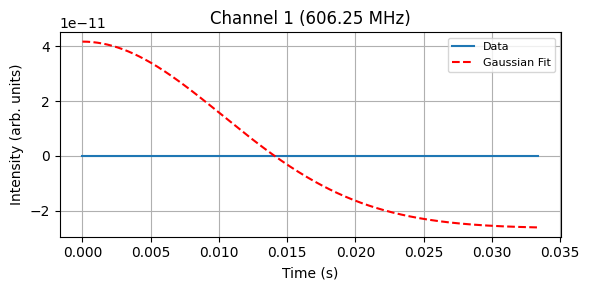

Channel 1 (606.25 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



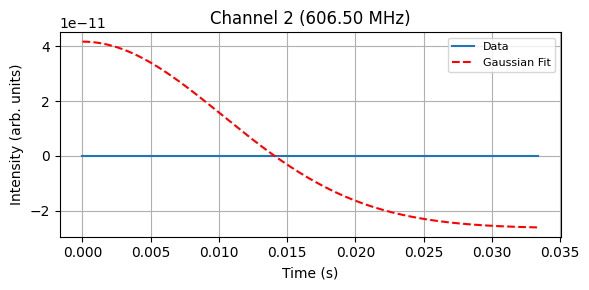

Channel 2 (606.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



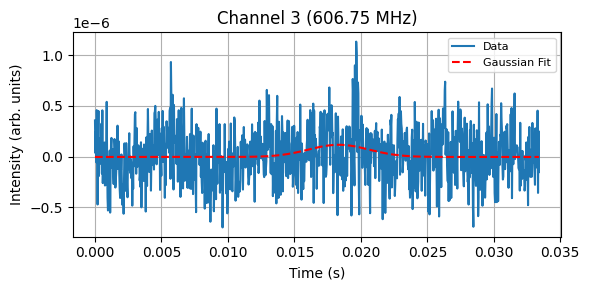

Channel 3 (606.75 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01834 ± 0.00063 s
  Sigma = 0.00227 ± 0.00069 s
  FWHM = 0.00535 ± 0.00162 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



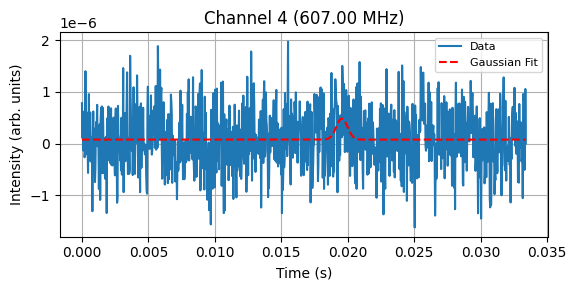

Channel 4 (607.00 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01956 ± 0.00018 s
  Sigma = 0.00042 ± 0.00018 s
  FWHM = 0.00099 ± 0.00042 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



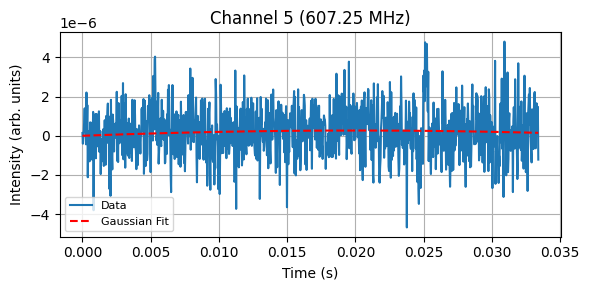

Channel 5 (607.25 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.02011 ± 0.00413 s
  Sigma = 0.06045 ± 2.39786 s
  FWHM = 0.14236 ± 5.64695 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



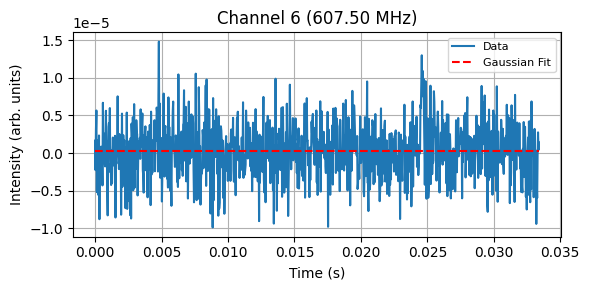

Channel 6 (607.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00608 ± 181610.77866 s
  Sigma = 0.06038 ± 1403.89938 s
  FWHM = 0.14220 ± 3306.18303 s
  Chi-squared = 0.01
  Reduced Chi-squared = 0.00



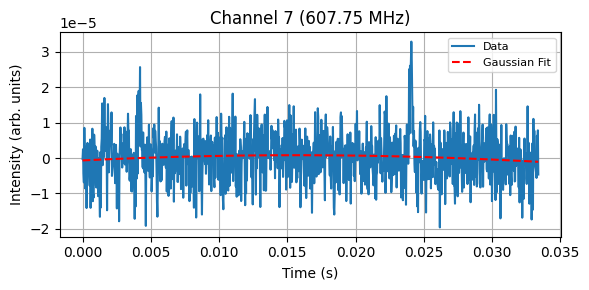

Channel 7 (607.75 MHz):
  Amplitude = 0.000 ± 0.023
  Mean = 0.01570 ± 0.00203 s
  Sigma = 0.09600 ± 9.92480 s
  FWHM = 0.22608 ± 23.37289 s
  Chi-squared = 0.06
  Reduced Chi-squared = 0.00



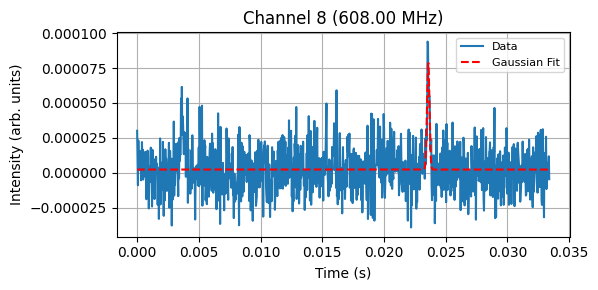

Channel 8 (608.00 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.02359 ± 0.00001 s
  Sigma = 0.00010 ± 0.00001 s
  FWHM = 0.00024 ± 0.00003 s
  Chi-squared = 0.08
  Reduced Chi-squared = 0.00



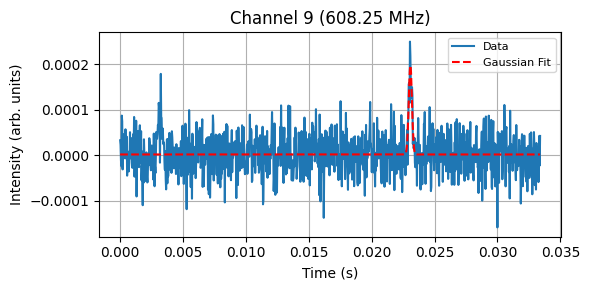

Channel 9 (608.25 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.02308 ± 0.00001 s
  Sigma = 0.00013 ± 0.00001 s
  FWHM = 0.00030 ± 0.00003 s
  Chi-squared = 0.71
  Reduced Chi-squared = 0.00



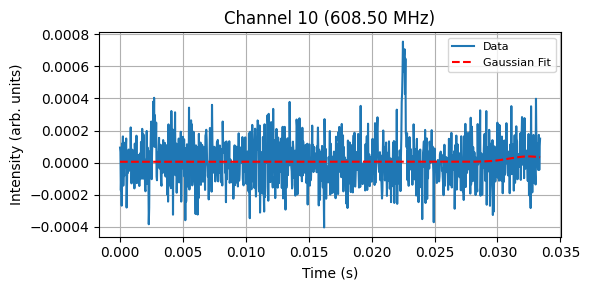

Channel 10 (608.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.03247 ± 0.00221 s
  Sigma = 0.00149 ± 0.00208 s
  FWHM = 0.00352 ± 0.00491 s
  Chi-squared = 3.21
  Reduced Chi-squared = 0.00



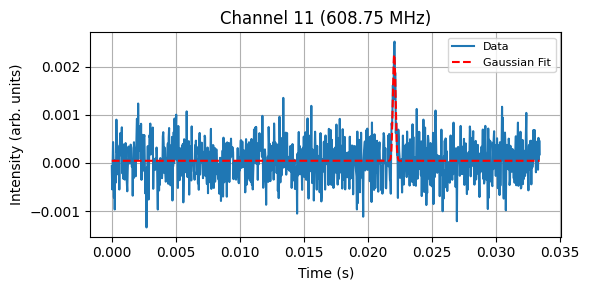

Channel 11 (608.75 MHz):
  Amplitude = 0.002 ± 0.000
  Mean = 0.02204 ± 0.00001 s
  Sigma = 0.00010 ± 0.00001 s
  FWHM = 0.00025 ± 0.00003 s
  Chi-squared = 3.49
  Reduced Chi-squared = 0.00



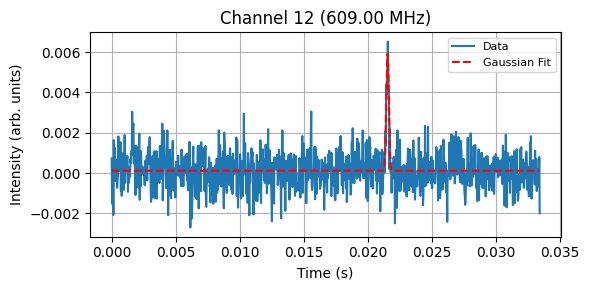

Channel 12 (609.00 MHz):
  Amplitude = 0.006 ± 0.000
  Mean = 0.02153 ± 0.00001 s
  Sigma = 0.00010 ± 0.00001 s
  FWHM = 0.00023 ± 0.00002 s
  Chi-squared = 6.62
  Reduced Chi-squared = 0.01



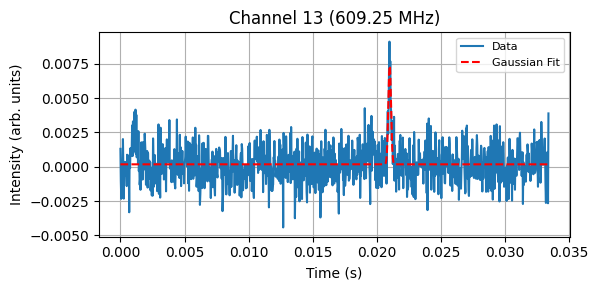

Channel 13 (609.25 MHz):
  Amplitude = 0.007 ± 0.001
  Mean = 0.02101 ± 0.00001 s
  Sigma = 0.00011 ± 0.00001 s
  FWHM = 0.00025 ± 0.00003 s
  Chi-squared = 9.65
  Reduced Chi-squared = 0.01



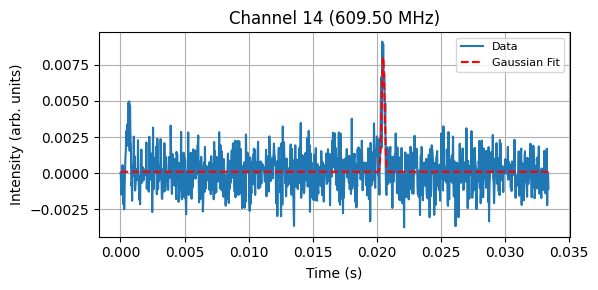

Channel 14 (609.50 MHz):
  Amplitude = 0.008 ± 0.001
  Mean = 0.02050 ± 0.00001 s
  Sigma = 0.00011 ± 0.00001 s
  FWHM = 0.00027 ± 0.00002 s
  Chi-squared = 18.63
  Reduced Chi-squared = 0.02



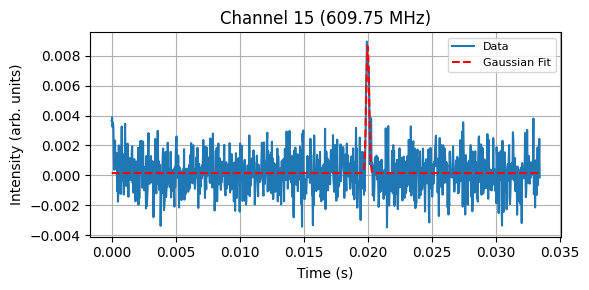

Channel 15 (609.75 MHz):
  Amplitude = 0.009 ± 0.001
  Mean = 0.01997 ± 0.00001 s
  Sigma = 0.00011 ± 0.00001 s
  FWHM = 0.00026 ± 0.00002 s
  Chi-squared = 10.54
  Reduced Chi-squared = 0.01



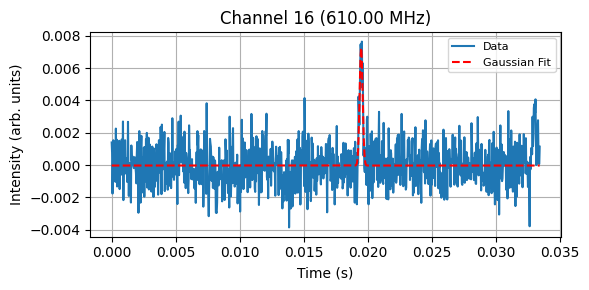

Channel 16 (610.00 MHz):
  Amplitude = 0.007 ± 0.001
  Mean = 0.01946 ± 0.00001 s
  Sigma = 0.00012 ± 0.00001 s
  FWHM = 0.00028 ± 0.00003 s
  Chi-squared = -50.25
  Reduced Chi-squared = -0.05



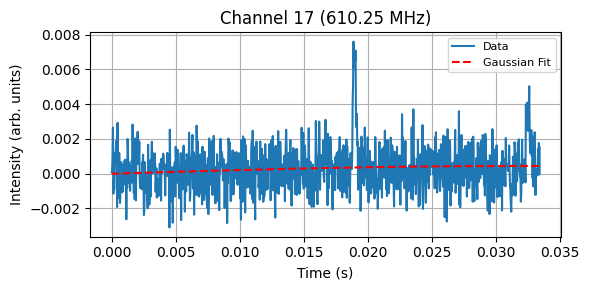

Channel 17 (610.25 MHz):
  Amplitude = 0.001 ± 0.010
  Mean = 0.03173 ± 0.02628 s
  Sigma = 0.03440 ± 0.18730 s
  FWHM = 0.08102 ± 0.44109 s
  Chi-squared = 15.76
  Reduced Chi-squared = 0.02



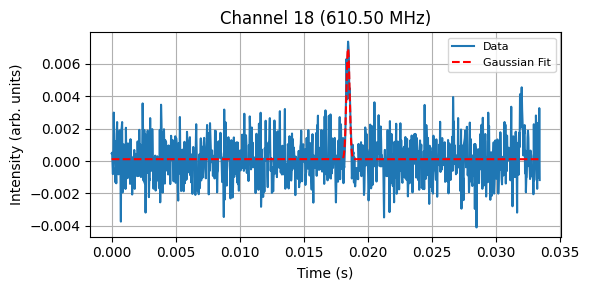

Channel 18 (610.50 MHz):
  Amplitude = 0.007 ± 0.001
  Mean = 0.01844 ± 0.00001 s
  Sigma = 0.00013 ± 0.00001 s
  FWHM = 0.00030 ± 0.00003 s
  Chi-squared = 14.39
  Reduced Chi-squared = 0.01



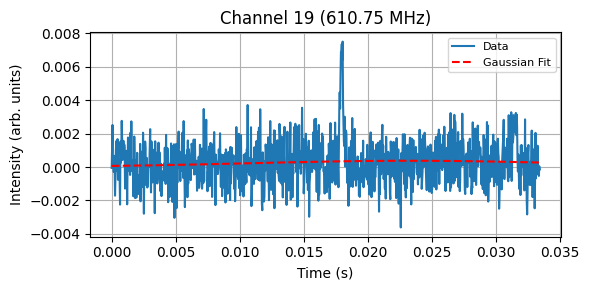

Channel 19 (610.75 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.02329 ± 0.00416 s
  Sigma = 0.01238 ± 0.01467 s
  FWHM = 0.02916 ± 0.03454 s
  Chi-squared = 7.85
  Reduced Chi-squared = 0.01



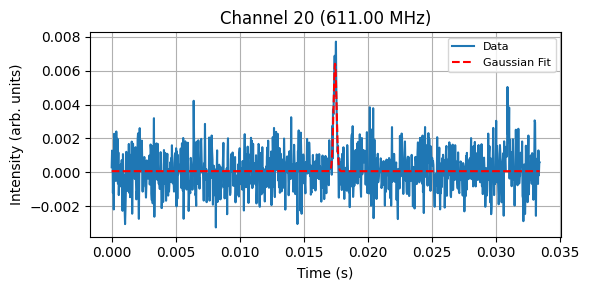

Channel 20 (611.00 MHz):
  Amplitude = 0.006 ± 0.001
  Mean = 0.01743 ± 0.00001 s
  Sigma = 0.00012 ± 0.00001 s
  FWHM = 0.00028 ± 0.00003 s
  Chi-squared = 21.52
  Reduced Chi-squared = 0.02



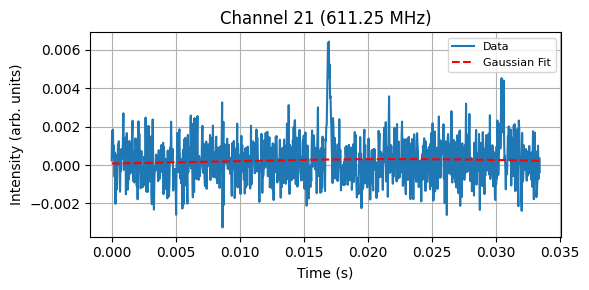

Channel 21 (611.25 MHz):
  Amplitude = 0.000 ± 0.001
  Mean = 0.02216 ± 0.00461 s
  Sigma = 0.01426 ± 0.02707 s
  FWHM = 0.03359 ± 0.06374 s
  Chi-squared = 6.32
  Reduced Chi-squared = 0.01



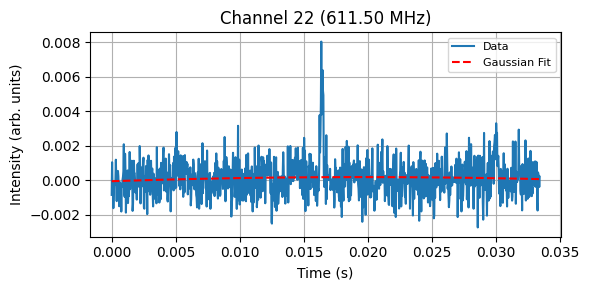

Channel 22 (611.50 MHz):
  Amplitude = 0.142 ± 341.994
  Mean = 0.01964 ± 0.00349 s
  Sigma = 0.33831 ± 406.48097 s
  FWHM = 0.79671 ± 957.26268 s
  Chi-squared = 21.89
  Reduced Chi-squared = 0.02



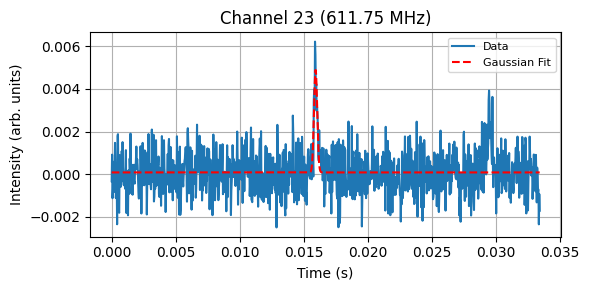

Channel 23 (611.75 MHz):
  Amplitude = 0.005 ± 0.000
  Mean = 0.01591 ± 0.00001 s
  Sigma = 0.00013 ± 0.00001 s
  FWHM = 0.00029 ± 0.00003 s
  Chi-squared = 10.67
  Reduced Chi-squared = 0.01



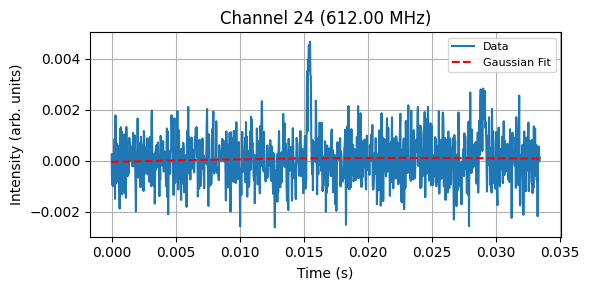

Channel 24 (612.00 MHz):
  Amplitude = 0.355 ± 4163.663
  Mean = 0.02337 ± 0.01021 s
  Sigma = 0.78267 ± 4587.99143 s
  FWHM = 1.84318 ± 10804.71983 s
  Chi-squared = 7.70
  Reduced Chi-squared = 0.01



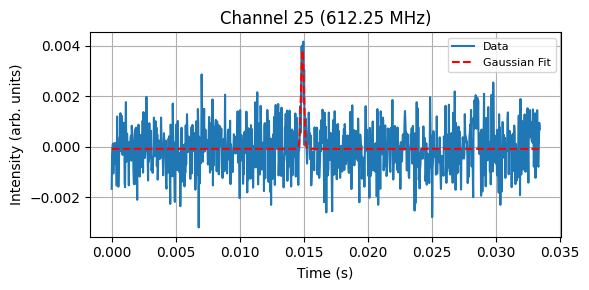

Channel 25 (612.25 MHz):
  Amplitude = 0.004 ± 0.000
  Mean = 0.01489 ± 0.00001 s
  Sigma = 0.00011 ± 0.00001 s
  FWHM = 0.00027 ± 0.00003 s
  Chi-squared = -8.79
  Reduced Chi-squared = -0.01



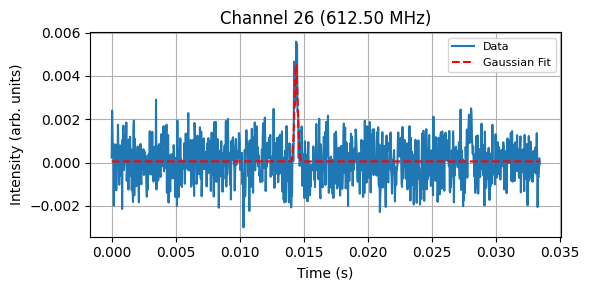

Channel 26 (612.50 MHz):
  Amplitude = 0.004 ± 0.000
  Mean = 0.01439 ± 0.00001 s
  Sigma = 0.00012 ± 0.00001 s
  FWHM = 0.00029 ± 0.00003 s
  Chi-squared = 16.00
  Reduced Chi-squared = 0.02



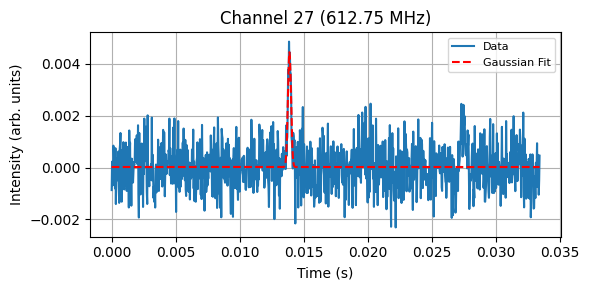

Channel 27 (612.75 MHz):
  Amplitude = 0.004 ± 0.000
  Mean = 0.01387 ± 0.00001 s
  Sigma = 0.00012 ± 0.00001 s
  FWHM = 0.00029 ± 0.00003 s
  Chi-squared = 32.45
  Reduced Chi-squared = 0.03



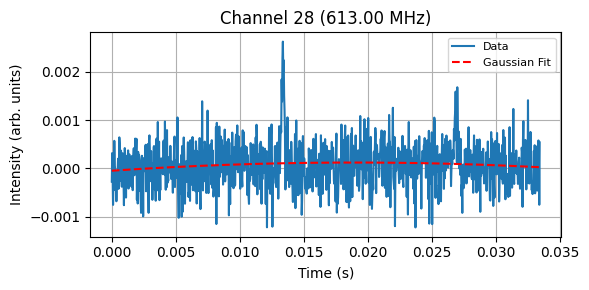

Channel 28 (613.00 MHz):
  Amplitude = 0.029 ± 12.596
  Mean = 0.01901 ± 0.00195 s
  Sigma = 0.17532 ± 38.37299 s
  FWHM = 0.41288 ± 90.36839 s
  Chi-squared = 4.14
  Reduced Chi-squared = 0.00



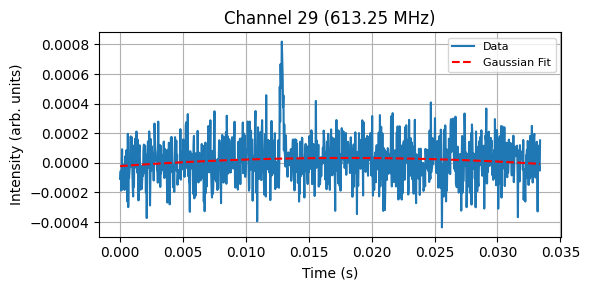

Channel 29 (613.25 MHz):
  Amplitude = 0.008 ± 2.657
  Mean = 0.01802 ± 0.00153 s
  Sigma = 0.15032 ± 26.04804 s
  FWHM = 0.35400 ± 61.34313 s
  Chi-squared = 0.58
  Reduced Chi-squared = 0.00



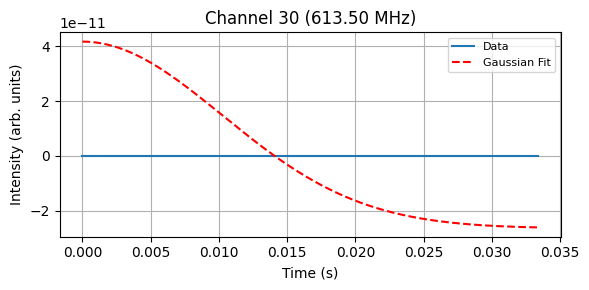

Channel 30 (613.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



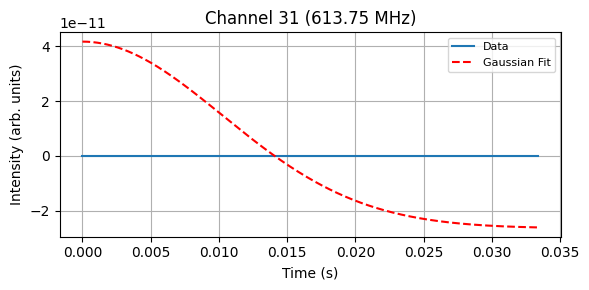

Channel 31 (613.75 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



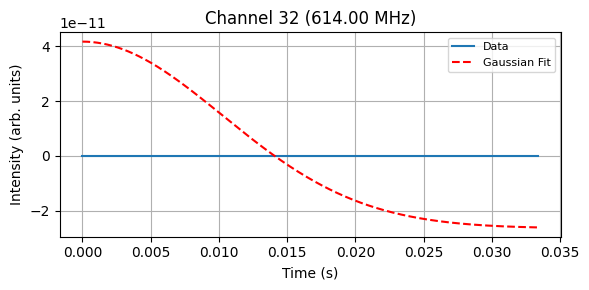

Channel 32 (614.00 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



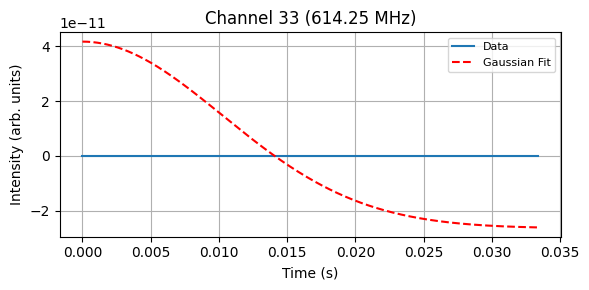

Channel 33 (614.25 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



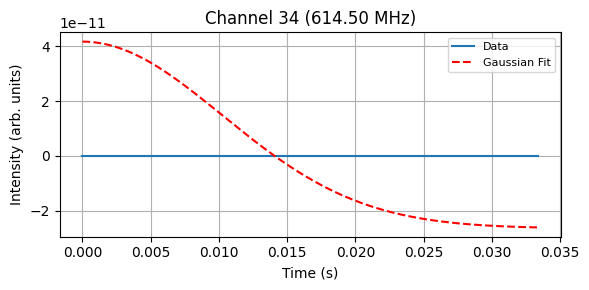

Channel 34 (614.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



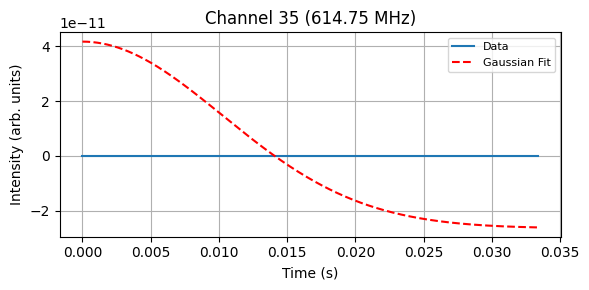

Channel 35 (614.75 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.00000 ± 0.00165 s
  Sigma = 0.01023 ± 0.00122 s
  FWHM = 0.02409 ± 0.00287 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



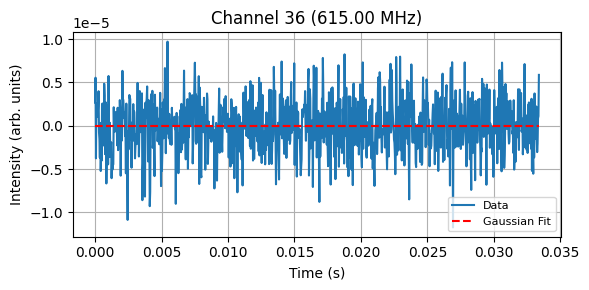

Channel 36 (615.00 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01914 ± 8989.38326 s
  Sigma = 0.09487 ± 1.11091 s
  FWHM = 0.22343 ± 2.61619 s
  Chi-squared = 0.01
  Reduced Chi-squared = 0.00



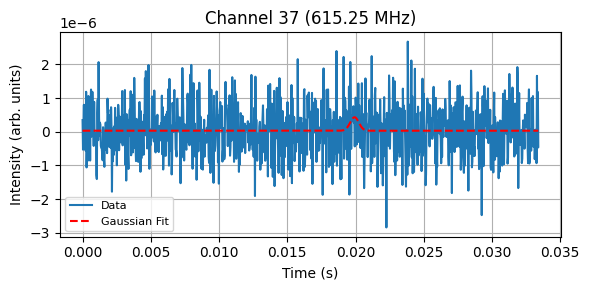

Channel 37 (615.25 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01993 ± 0.00021 s
  Sigma = 0.00032 ± 0.00021 s
  FWHM = 0.00075 ± 0.00049 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



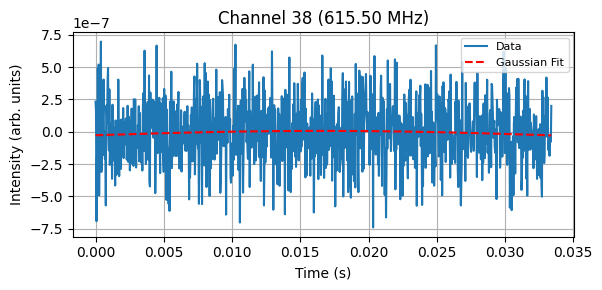

Channel 38 (615.50 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01655 ± 0.00333 s
  Sigma = 0.01918 ± 0.14661 s
  FWHM = 0.04517 ± 0.34527 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



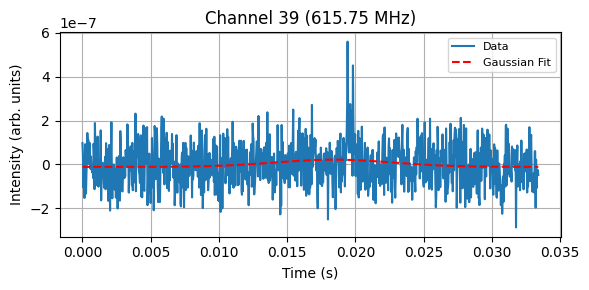

Channel 39 (615.75 MHz):
  Amplitude = 0.000 ± 0.000
  Mean = 0.01840 ± 0.00116 s
  Sigma = 0.00433 ± 0.00152 s
  FWHM = 0.01020 ± 0.00358 s
  Chi-squared = 0.00
  Reduced Chi-squared = 0.00



In [ ]:
from scipy.optimize import curve_fit as cf
x = np.linspace(0, period, nphase)

def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + C

def fitfunc(x, m, c):
    return m * x + c

fwhm_list = []
fwhm_error_list = []
mu_list = []
mu_error_list = []

x = np.linspace(0, period, nphase)

for i in range(nchan):
    y = time_averaged[i, :]

    try:
        # Fit Gaussian to the data
        popt, pcov = cf(
            gaussian,
            x,
            y,
            p0=[np.max(y), x[np.argmax(y)], 0.01, np.min(y)],
            bounds=([0, 0, 0, -np.inf], [np.inf, period, np.inf, np.inf])
        )

        # Extract fit parameters and errors
        A, mu, sigma, C = popt
        param_error = np.sqrt(np.diag(pcov))

        # FWHM and error
        FWHM = 2.355 * sigma
        sigma_error = param_error[2]
        FWHM_error = 2.355 * sigma_error

        # Append to lists
        fwhm_list.append(FWHM)
        fwhm_error_list.append(FWHM_error)
        mu_list.append(mu)
        mu_error_list.append(param_error[1])

        # Generate fitted curve
        x_fit = np.linspace(0, period, 1000)
        y_fit = gaussian(x_fit, *popt)

        # Residuals and reduced chi-squared
        expected = gaussian(x, *popt)
        residuals = y - expected
        chi_squared = np.sum((residuals ** 2) / (expected + 1e-6))
        dof = len(y) - len(popt)
        reduced_chi_squared = chi_squared / dof

        # Plot per-channel fit
        plt.figure(figsize=(6, 3))
        plt.plot(x, y, label='Data')
        plt.plot(x_fit, y_fit, 'r--', label='Gaussian Fit')
        plt.title(f"Channel {i} ({freq[i]:.2f} MHz)")
        plt.xlabel('Time (s)')
        plt.ylabel('Intensity (arb. units)')
        plt.grid(True)
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

        # Print summary
        print(f"Channel {i} ({freq[i]:.2f} MHz):")
        print(f"  Amplitude = {A:.3f} ± {param_error[0]:.3f}")
        print(f"  Mean = {mu:.5f} ± {param_error[1]:.5f} s")
        print(f"  Sigma = {sigma:.5f} ± {param_error[2]:.5f} s")
        print(f"  FWHM = {FWHM:.5f} ± {FWHM_error:.5f} s")
        print(f"  Chi-squared = {chi_squared:.2f}")
        print(f"  Reduced Chi-squared = {reduced_chi_squared:.2f}\n")

    except RuntimeError:
        print(f"Channel {i} ({freq[i]:.2f} MHz): Fit failed.\n")
        fwhm_list.append(np.nan)
        fwhm_error_list.append(np.nan)
        mu_list.append(np.nan)
        mu_error_list.append(np.nan)






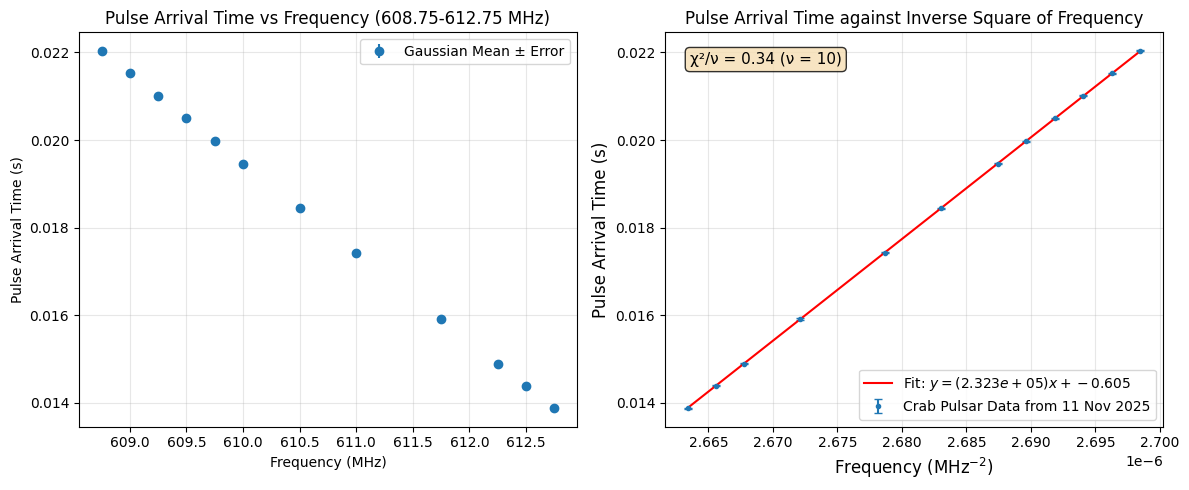

LINEAR FIT STATISTICS
Number of data points: 12
Degrees of freedom (ν): 10
Chi-squared (χ²): 3.403
Reduced chi-squared (χ²/ν): 0.340
R-squared: 1.0000

FIT PARAMETERS
Gradient (slope): 2.323e+05 ± 2.875e+02
Intercept: -0.605 ± 0.001

DM value: 5.598e+01 ± 6.928e-02

GOODNESS OF FIT ASSESSMENT:
Note: χ²/ν < 1 - Possibly overestimated errors or good fit


In [ ]:
# Defining linear fit
def fitfunc(x, m, c):
    return m * x + c

# Convert to numpy arrays
freq_array = np.array(freq)
mu_array = np.array(mu_list)
mu_err_array = np.array(mu_error_list)

#Combined mask (19th)
combined_mask = (
    ~np.isnan(mu_array) &                        # Remove NaN values from mu_array
    ~np.isnan(mu_err_array) &                    # Remove NaN values from mu_err_array
  (np.isin(freq_array, [608.75, 609.00, 609.25, 609.50, 609.75, 610.00, 610.50, 611.0, 611.75, 612.25, 612.50, 612.75]))
)

#Combined Mask (11th)
# combined_mask = (
#     ~np.isnan(mu_array) &                        # Remove NaN values from mu_array
#     ~np.isnan(mu_err_array) &                    # Remove NaN values from mu_err_array
#   (np.isin(freq_array, [610.25,611.25,611.5,612.25, 612.50, 613]))
#)


#Unfiltered!
# clean_freq = freq_array
# clean_mu = mu_array
# clean_mu_err = mu_err_array


# Apply the combined mask
clean_freq = freq_array[combined_mask]
clean_mu = mu_array[combined_mask]
clean_mu_err = mu_err_array[combined_mask]

# Compute values for plotting
values = clean_freq**(-2)

# Fit a straight line, weighting by mu_error_clean
popt, pcov = cf(fitfunc, values, clean_mu, sigma=clean_mu_err, absolute_sigma=True)
m_fit, c_fit = popt
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Generate smooth x-values for plotting the fit line
x_fit = np.linspace(values.min(), values.max(), 500)
y_fit = fitfunc(x_fit, *popt)

# ====================================================
# Chi-squared calculation for the linear fit
# ====================================================

# Calculate predicted values at the data points
y_pred = fitfunc(values, m_fit, c_fit)

# Calculate residuals
residuals = clean_mu - y_pred

# Calculate chi-squared
chi2 = np.sum((residuals / clean_mu_err)**2)

# Degrees of freedom: n_data - n_parameters
n_data = len(clean_mu)
n_params = 2  # slope and intercept
dof = n_data - n_params

# Reduced chi-squared
reduced_chi2 = chi2 / dof

# Calculate R-squared (coefficient of determination)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((clean_mu - np.mean(clean_mu))**2)
r_squared = 1 - (ss_res / ss_tot)

# ====================================================
# Create subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot (Pulse Arrival Time vs Frequency)
ax1.errorbar(clean_freq, clean_mu, yerr=clean_mu_err,
             fmt='o', label='Gaussian Mean ± Error')
ax1.set_xlabel('Frequency (MHz)')
ax1.set_ylabel('Pulse Arrival Time (s)')
ax1.set_title('Pulse Arrival Time vs Frequency (608.75-612.75 MHz)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Second plot (Data with error bars and fit)
ax2.errorbar(values, clean_mu, yerr=clean_mu_err, fmt='.', capsize=3,
             label='Crab Pulsar Data from 11 Nov 2025')
ax2.plot(x_fit, y_fit, 'r-', label=f'Fit: $y = ({m_fit:.3e}) x + {c_fit:.3f}$')

# Set titles and labels with LaTeX formatting
ax2.set_title("Pulse Arrival Time against Inverse Square of Frequency", fontsize=12)
ax2.set_xlabel("Frequency (MHz$^{-2}$)", fontsize=12)
ax2.set_ylabel("Pulse Arrival Time (s)", fontsize=12)

ax2.grid(True, alpha=0.3)

# Add chi-squared information to the plot
chi_text = f'χ²/ν = {reduced_chi2:.2f} (ν = {dof})'
ax2.text(0.05, 0.95, chi_text, transform=ax2.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Increase legend size with more customization
legend = ax2.legend(fontsize=10, loc='best', frameon=True, fancybox=True)

# Adjust layout to avoid overlap
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/Year 3 Lab/Pulsar/Crabbing_It/Results/Freq Intensity/Freq Intensity B0531+21 (11-11-25).png",
#            dpi=500, bbox_inches="tight")


# Show the combined plot
plt.show()

# ====================================================
# Print statistics and results
# ====================================================
print("="*50)
print("LINEAR FIT STATISTICS")
print("="*50)
print(f"Number of data points: {n_data}")
print(f"Degrees of freedom (ν): {dof}")
print(f"Chi-squared (χ²): {chi2:.3f}")
print(f"Reduced chi-squared (χ²/ν): {reduced_chi2:.3f}")
print(f"R-squared: {r_squared:.4f}")
print("="*50)
print("\nFIT PARAMETERS")
print("="*50)
print(f"Gradient (slope): {m_fit:.3e} ± {perr[0]:.3e}")
print(f"Intercept: {c_fit:.3f} ± {perr[1]:.3f}")
print("="*50)

# Calculate DM value
DM = 2.41*10**(-4) * m_fit
DM_err = 2.41*10**(-4) * perr[0]
print(f"\nDM value: {DM:.3e} ± {DM_err:.3e}")

# Goodness of fit assessment
print("\nGOODNESS OF FIT ASSESSMENT:")
if abs(reduced_chi2 - 1) < 0.5:
    print("✓ Good fit (χ²/ν ≈ 1)")
elif reduced_chi2 < 1:
    print("Note: χ²/ν < 1 - Possibly overestimated errors or good fit")
else:
    print(f"Note: χ²/ν > 1 - Fit may not fully capture data structure (χ²/ν = {reduced_chi2:.2f})")

In [ ]:
ne = 0.016428
distance = DM / ne
dist_uncert = (1/ne)*(DM_err)
print(distance, dist_uncert)

3407.8975896648335 4.216926599741864


# Is the Pulsar above the horizon?

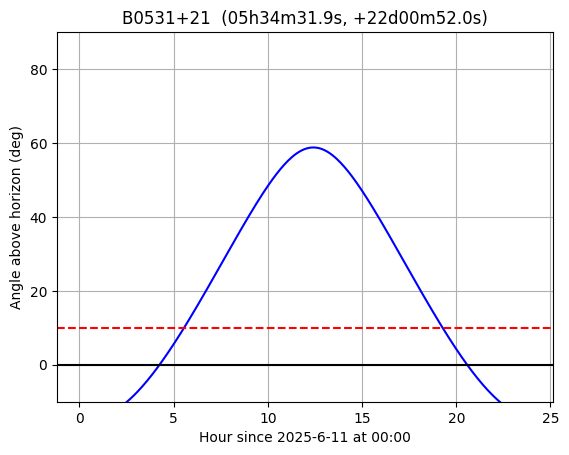

In [ ]:
import numpy as np
import astropy.coordinates as coord
import astropy.units as u
import astropy.time as atime
import matplotlib.pyplot as plt

# Date and telescope location
day = "2025-6-11" #YYYY - MM - DD
t0 = atime.Time(day)
telescope = coord.EarthLocation(lat=53.2366243*u.deg, lon=-2.3091195*u.deg)
dt = atime.TimeDelta(np.arange(360)*240, format='sec')
t = t0 + dt
x = 24*(t.mjd - t0.mjd)

# List of pulsars with RA/Dec from Appendix E
pulsars = {
    # "B0833-45": ("08h35m20.6s", "-45d10m34.8s"),
    # "B1641-45": ("16h44m49.2s", "-45d59m09.5s"),
    # "B0329+54": ("03h32m59.3s", "+54d34m43.5s"),
    # "J0437-4715": ("04h37m15.8s", "-47d15m09.1s"),
    # "B0950+08": ("09h53m09.3s", "+07d55m35.7s"),
    # "B0736-40": ("07h38m32.3s", "-40d42m40.9s"),
    # "B1451-68": ("14h56m00.1s", "-68d43m39.2s"),
    # "B1933+16": ("19h35m47.8s", "+16d16m39.9s"),
    # "B1556-44": ("15h59m41.5s", "-44d38m45.9s"),
    #"B2020+28": ("20h22m37.0s", "+28d54m23.1s"),
    #"B1929+10": ("19h32m13.9s", "+10d59m32.4s"),
    #"B1133+16": ("11h36m03.2s", "+15d51m04.4s"),
    #"B2016+28": ("20h18m03.8s", "+28d39m54.2s"),
    # "B2021+51": ("20h22m49.8s", "+51d54m50.2s"),
    # "B0628-28": ("06h30m49.4s", "-28d34m42.7s"),
    # "B0355+54": ("03h58m53.7s", "+54d13m13.7s"),
    # "B1642-03": ("16h45m02.0s", "-03d17m58.3s"),
    # "B1054-62": ("10h56m25.5s", "-62d58m47.6s"),
    # "B2111+46": ("21h13m24.3s", "+46d44m08.8s"),
    # "B1749-28": ("17h52m58.6s", "-28d06m37.3s"),
    # "B2154+40": ("21h57m01.8s", "+40d17m45.9s"),
    # "B1557-50": ("16h00m53.0s", "-50d44m20.9s"),
    # "B1648-42": ("16h51m48.7s", "-42d46m11.0s"),
    # "B1323-62": ("13h27m17.4s", "-62d22m44.6s"),
    # "B0835-41": ("08h37m21.1s", "-41d35m14.3s"),
    # "B2310+42": ("23h13m08.6s", "+42d53m13.0s"),
    # "B1804-08": ("18h07m38.0s", "-08d47m43.2s"),
    # "B0740-28": ("07h42m49.0s", "-28d22m43.7s"),
    # "B1449-64": ("14h53m32.7s", "-64d13m15.5s"),
    "B0531+21": ("05h34m31.9s", "+22d00m52.0s"),
    # "B0403-76": ("04h01m51.6s", "-76d08m13.8s"),
    # "B1800-21": ("18h03m51.4s", "-21d37m07.3s"),
    # "J0248+6021": ("02h48m18.6s", "+60d21m34.7s"),
    # "B1937+21": ("19h39m38.5s", "+21d34m59.1s"),
    # "B2045-16": ("20h48m35.6s", "-16d16m44.5s"),
}


for name, (ra, dec) in pulsars.items():
    target = coord.SkyCoord(ra=ra, dec=dec, frame="icrs")
    altaz = target.transform_to(coord.AltAz(obstime=t, location=telescope))
    alt = altaz.alt.deg

    plt.plot(x, alt, color = 'b')
    plt.grid()
    plt.axhline(0, color='k')
    plt.axhline(10, color='red', linestyle ='dashed')
    plt.ylim(-10, 90)
    plt.title(f"{name}  ({ra}, {dec})")
    plt.xlabel(f"Hour since {day} at 00:00")
    plt.ylabel("Angle above horizon (deg)")
    plt.savefig(name+".png")
    plt.show()
